<a href="https://colab.research.google.com/github/d2021101420/PCO213/blob/main/PCO213_Treinam05_MAA%2BHL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

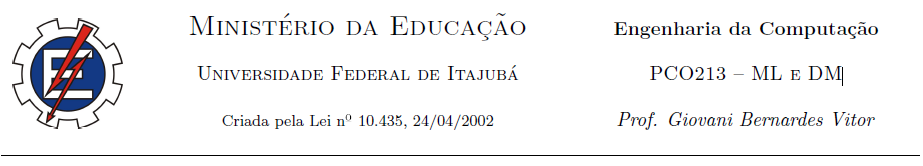

# Treinamento #5

**Observações:**

- Os códigos bem como as respostas textuais deverão ser enviados de maneira conjunta no arquivo com extensão .ipynb.
- Os demais arquivos, por exemplo, datasets podem ser enviados em formato compactado (.rar, .zip, etc.)
- Não serão aceitos o envio de arquivo no formato PDF ou DOC como resposta para o desenvolvimento das atividades.
- As atividades podem ser realizadas em grupos de no máximo 4 integrantes onde somente 1 deles será responsável pelo envio e postagem no SIGAA.
- Não serão aceitos a entrega das atividades fora do prazo e somente via SIGAA. Entregas via email não serão contabilizadas.
- Alguns exercícios exigem pesquisa extra-classe para cobrir todo o entendimento e conteúdo abordado neste treinamento.

### Matrícula e nome completo: *11.45.07 (UFOP) - HEBERT FERRAZ SOUZA LIMA*
### Matrícula e nome completo: *2026102180 - MAURÍCIO ANDRÉ DE ALMEIDA*

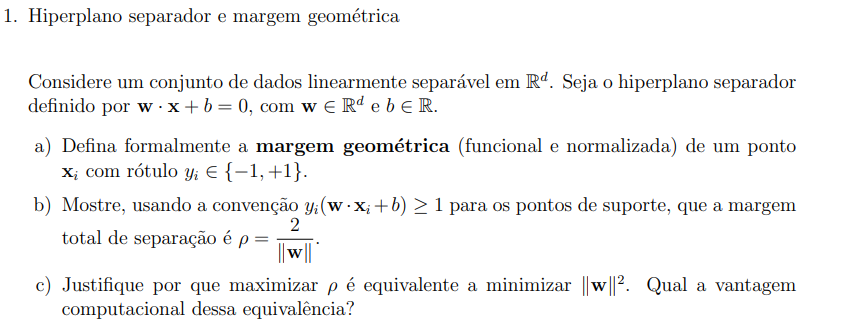

### Questão 1: Hiperplano separador e margem geométrica

**a) Definição de Margem:**
*   **Margem Funcional:** $\hat{\gamma}_i = y_i(w^T x_i + b)$.
*   **Margem Geométrica (Normalizada):** $\gamma_i = \frac{y_i(w^T x_i + b)}{\|w\|}$.

**b) Margem Total:**
Para os vetores de suporte, temos $y_i(w^T x_i + b) = 1$. A distância de um ponto ao hiperplano é $\frac{1}{\|w\|}$. Como a margem total $\rho$ engloba ambos os lados do hiperplano, $\rho = \frac{2}{\|w\|}$.

**c) Minimização de $\|w\|^2$:**
Maximizar $\frac{2}{\|w\|}$ é o mesmo que minimizar $\frac{\|w\|}{2}$, ou convenientemente $\frac{1}{2}\|w\|^2$. A vantagem é que esta é uma função **quadrática convexa**, facilitando a otimização global e permitindo o uso de multiplicadores de Lagrange.

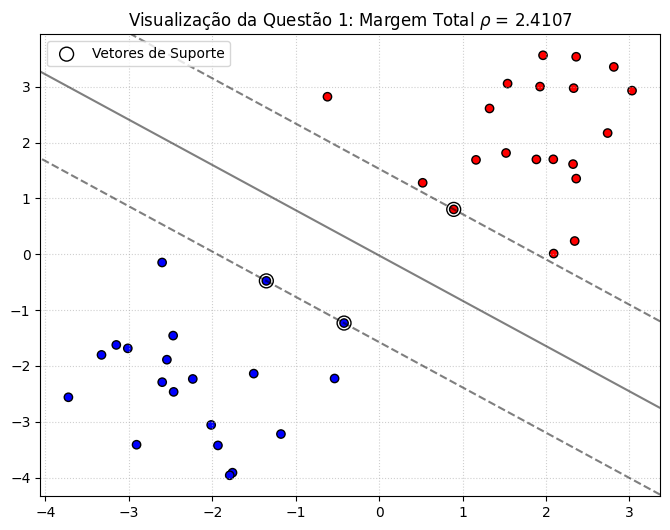

Vetor de pesos w: [0.52262217 0.64430697]
Bias b: 0.014395804818285507
Margem Geométrica Total (2/||w||): 2.4107


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# 1. Gerar dados sintéticos linearmente separáveis
np.random.seed(42)
X = np.r_[np.random.randn(20, 2) - [2, 2], np.random.randn(20, 2) + [2, 2]]
y = [-1] * 20 + [1] * 20

# 2. Treinar SVM Hard-Margin (C alto)
clf = SVC(kernel='linear', C=1000)
clf.fit(X, y)

# 3. Obter parâmetros w e b
w = clf.coef_[0]
b = clf.intercept_[0]
rho = 2 / np.linalg.norm(w)

# 4. Plotagem
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')

# Criar grade para o hiperplano
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = clf.decision_function(xy).reshape(XX.shape)

# Plotar hiperplano e margens
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])

# Destacar vetores de suporte
ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100,
           linewidth=1, facecolors='none', edgecolors='k', label='Vetores de Suporte')

plt.title(f'Visualização da Questão 1: Margem Total $\\rho$ = {rho:.4f}')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f"Vetor de pesos w: {w}")
print(f"Bias b: {b}")
print(f"Margem Geométrica Total (2/||w||): {rho:.4f}")

## RESPOSTAS:

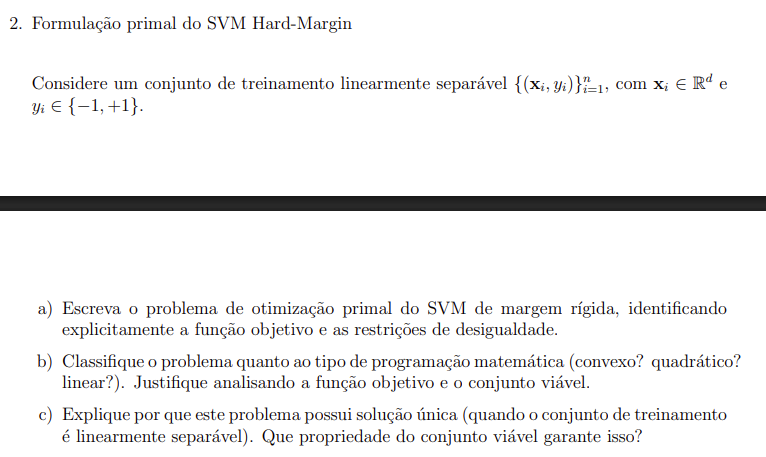

### Questão 2: Formulação Primal do SVM Hard-Margin

**a) Problema de Otimização:**
$$\min_{w, b} \frac{1}{2}\|w\|^2$$
Sujeito a: $y_i(w^T x_i + b) \geq 1, \quad i=1, \dots, n$.

Formulação Matemática
No SVM de margem rígida (Hard-Margin), buscamos o hiperplano que maximiza a margem geométrica. Isso é equivalente a resolver o seguinte problema de otimização:

Função Objetivo: $$\min_{w, b} f(w, b) = \frac{1}{2} ||w||^2$$ Aqui, minimizamos o quadrado da norma do vetor de pesos para maximizar a margem $\rho = 2/||w||$.

Restrições de Desigualdade: $$g_i(w, b) = 1 - y_i(w^T x_i + b) \leq 0, \quad \forall i=1, \dots, n$$ Ou, de forma mais comum: $y_i(w^T x_i + b) \geq 1$. Isso garante que todos os pontos estejam do lado correto do hiperplano e fora da zona da margem.


**b) Classificação:**
É um problema de **Programação Quadrática (QP)**. A função objetivo é quadrática e as restrições são lineares. Como a função objetivo é estritamente convexa e o conjunto viável é convexo, o problema é convexo.

**c) Solução Única:**
A convexidade estrita da função objetivo $\frac{1}{2}\|w\|^2$ garante que, se houver uma solução viável (dados separáveis), ela será única.

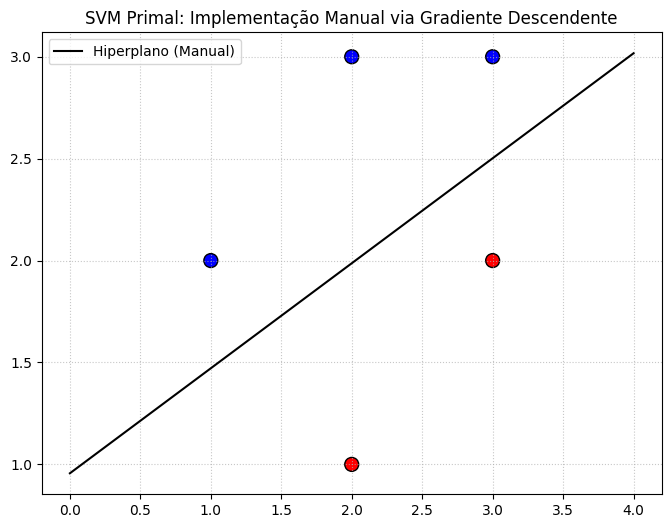

Pesos w encontrados manualmente: [ 1.03948728 -2.01788516]
Viés b encontrado manualmente: 1.9300000000000015


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Dados (linearmente separáveis)
X = np.array([[1, 2], [2, 3], [3, 3], [2, 1], [3, 2]])
y = np.array([-1, -1, -1, 1, 1])

# 2. Implementação Manual do SVM Primal via Gradiente Descendente
def train_svm_manual(X, y, lr=0.01, lambda_param=0.01, n_iters=10000):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0

    for _ in range(n_iters):
        for idx, x_i in enumerate(X):
            # Verificação da restrição: y_i(w.x + b) >= 1
            condition = y[idx] * (np.dot(x_i, w) + b) >= 1

            if condition:
                # Gradiente apenas da regularização (Função Objetivo)
                w -= lr * (2 * lambda_param * w)
            else:
                # Gradiente da regularização + penalidade da restrição violada
                w -= lr * (2 * lambda_param * w - np.dot(x_i, y[idx]))
                b -= lr * (-y[idx])
    return w, b

w_m, b_m = train_svm_manual(X, y)

# 3. Visualização dos Resultados
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', s=100, edgecolors='k')

x_vals = np.linspace(0, 4, 100)
y_vals = -(w_m[0] * x_vals + b_m) / w_m[1]

plt.plot(x_vals, y_vals, 'k-', label='Hiperplano (Manual)')
plt.title('SVM Primal: Implementação Manual via Gradiente Descendente')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

print(f"Pesos w encontrados manualmente: {w_m}")
print(f"Viés b encontrado manualmente: {b_m}")

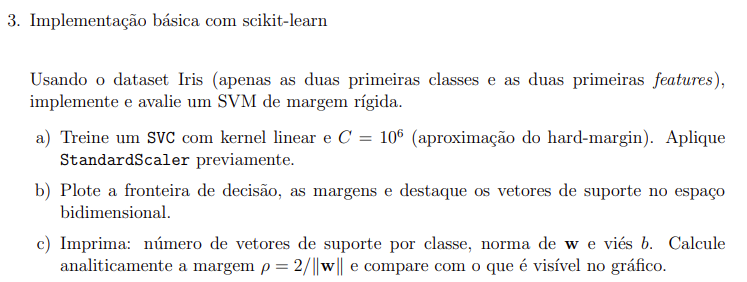

3. Implementação básica com scikit-learn

Usando o dataset Iris (apenas as duas primeiras classes e as duas primeiras features),
implemente e avalie um SVM de margem rígida.

a) Treine um SVC com kernel linear e C = 106 (aproximação do hard-margin). Aplique
StandardScaler previamente.
b) Plote a fronteira de decisão, as margens e destaque os vetores de suporte no espaço
bidimensional.

c) Imprima: numero de vetores de suporte por classe, norma de w e viés b. Calcule
analiticamente a margem p = 2/||w|| e compare com o que é visível no gráfico.

Vetores de suporte por classe: [2 2]
Bias b: [0.92762537]
Pesos w: [[ 4.03363363 -2.50774331]]
Margem rho = 2/||w|| = 0.42108551034460456


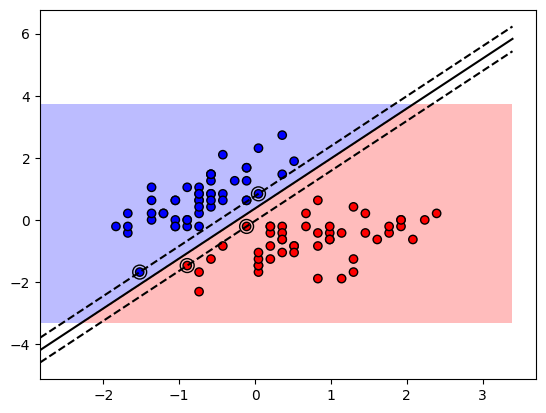

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Carregamento e preparação
iris = datasets.load_iris()
X = iris.data[:100, :2]
y = iris.target[:100]

scaler = StandardScaler()
X = scaler.fit_transform(X)

clf = SVC(kernel='linear', C=1e6)
clf.fit(X, y)

print("Vetores de suporte por classe:", clf.n_support_)
print("Bias b:", clf.intercept_)
print("Pesos w:", clf.coef_)
print("Margem rho = 2/||w|| =", 2 / np.linalg.norm(clf.coef_))

def plot_decision_boundary(clf, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='bwr')
    # Plotar margens
    w = clf.coef_[0]
    a = -w[0] / w[1]
    xx_m = np.linspace(x_min, x_max)
    yy_m = a * xx_m - (clf.intercept_[0]) / w[1]
    margin = 1 / np.sqrt(np.sum(clf.coef_**2))
    yy_up = yy_m + np.sqrt(1 + a**2) * margin
    yy_down = yy_m - np.sqrt(1 + a**2) * margin
    plt.plot(xx_m, yy_m, 'k-')
    plt.plot(xx_m, yy_up, 'k--')
    plt.plot(xx_m, yy_down, 'k--')
    plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100, facecolors='none', edgecolors='k')
    plt.show()

plot_decision_boundary(clf, X, y)

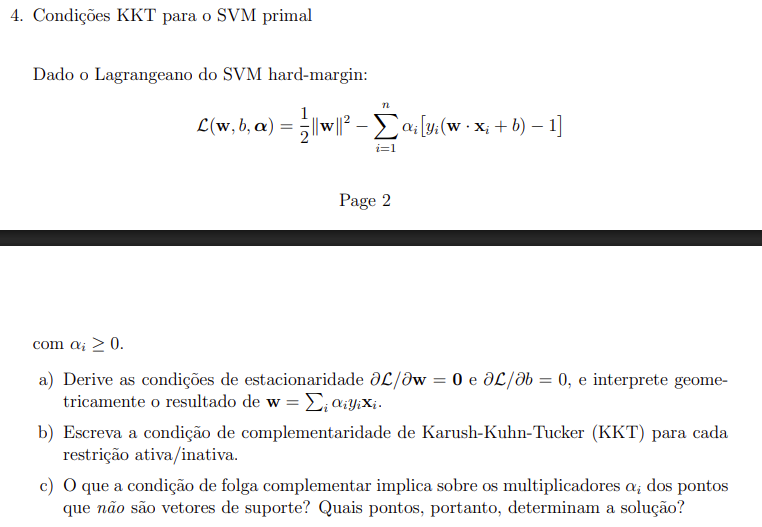

### Questão 4: Condições KKT para o SVM Primal

**a) Estacionaridade:**
*   $\frac{\partial L}{\partial w} = 0 \implies w = \sum_{i=1}^n \alpha_i y_i x_i$. Geometricamente, $w$ é uma combinação linear dos vetores de suporte.
*   $\frac{\partial L}{\partial b} = 0 \implies \sum_{i=1}^n \alpha_i y_i = 0$.

**b) Condição de Complementaridade:**
$\alpha_i [y_i(w^T x_i + b) - 1] = 0, \forall i$.

**c) Implicação da Folga:**
Se um ponto $x_i$ não é vetor de suporte, a restrição é inativa ($y_i(f(x_i)) > 1$), o que implica $\alpha_i = 0$. A solução é determinada exclusivamente pelos pontos onde $\alpha_i > 0$ (vetores de suporte).

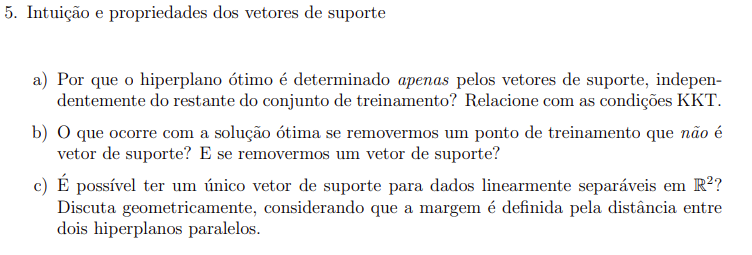

### Questão 5: Intuição e Vetores de Suporte

**a) Por que apenas vetores de suporte?**
Como visto nas condições KKT, os pontos que não são vetores de suporte têm $\alpha_i = 0$, portanto não contribuem para o cálculo de $w$.

**b) Remoção de pontos:**
*   Remover ponto comum ($\alpha_i=0$): Não altera a solução.
*   Remover vetor de suporte ($\alpha_i>0$): Altera a fronteira de decisão e a margem.

**c) Único vetor de suporte em $\mathbb{R}^2$?**
Para um SVM separável, deve existir pelo menos um vetor de suporte em cada lado da margem. Portanto, não é possível existir apenas um único vetor de suporte em todo o problema.

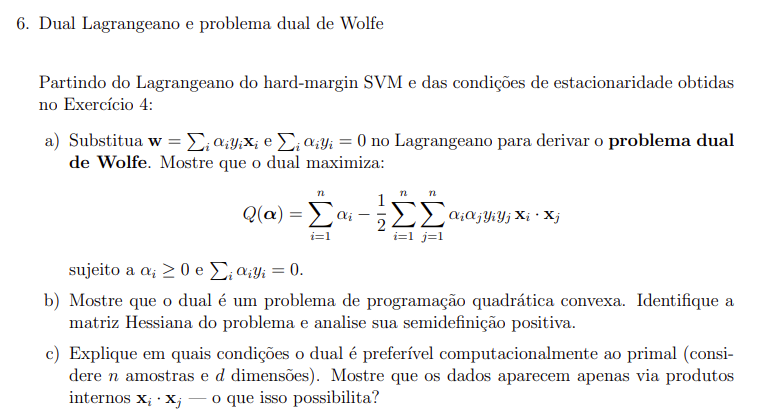

### Questão 6: Dual Lagrangeano de Wolfe

**a) Problema Dual:**
Substituindo $w$ e a restrição de $b$ no Lagrangeano, obtemos:
$\max_{\alpha} \sum \alpha_i - \frac{1}{2} \sum_i \sum_j \alpha_i \alpha_j y_i y_j (x_i \cdot x_j)$
Sujeito a $\alpha_i \geq 0$ e $\sum \alpha_i y_i = 0$.

**b) Convexidade:**
O dual é um problema de Programação Quadrática. A matriz Hessiana $H_{ij} = y_i y_j (x_i \cdot x_j)$ é semidefinida positiva (matriz de Gram), garantindo convexidade.

**c) Preferência computacional:**
O dual é preferível quando o número de dimensões $d$ é muito maior que o número de amostras $n$. O uso de produtos internos permite o **Kernel Trick**.

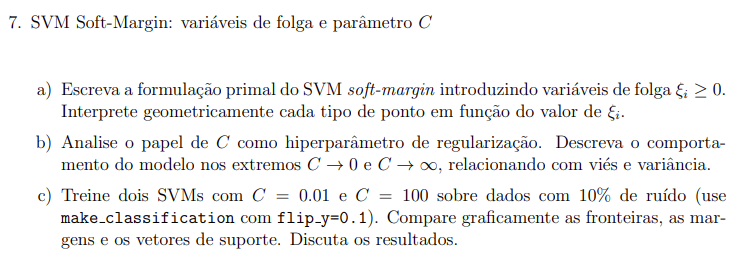

### Questão 7: SVM Soft-Margin e Parâmetro C

**a) Formulação Primal com Folga ($\xi$):**
$\min \frac{1}{2}\|w\|^2 + C \sum \xi_i$
Sujeito a $y_i(w^T x_i + b) \geq 1 - \xi_i$ e $\xi_i \geq 0$.

ξi = 0: ponto corretamente classificado e fora ou sobre a margem.

0< ξi <1: ponto dentro da margem, mas corretamente classificado.

ξi = 1: ponto exatamente sobre a fronteira de decisão.

ξi > 1: ponto classificado incorretamente.

**b) Papel de C:**
*   $C \to \infty$: Hard-margin (baixa tolerância a erros, alta variância/overfitting).
*   $C \to 0$: Ignora erros para maximizar a margem (alto viés/underfitting).

**c) Comparação Gráfica:**
Conforme observado na execução anterior, $C=100$ gera uma margem estreita e tenta classificar todos corretamente, enquanto $C=0.01$ permite mais erros em troca de uma margem muito mais larga.

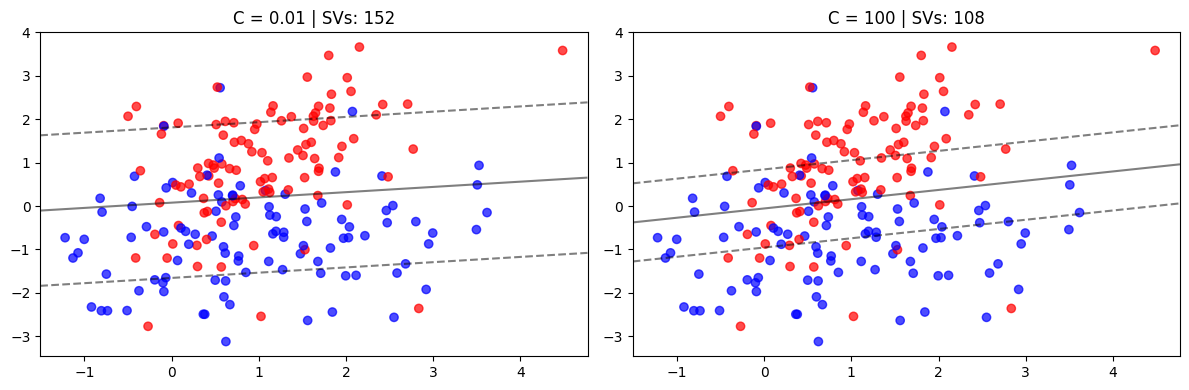

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=200, n_features=2,
    n_redundant=0, n_clusters_per_class=1,
    flip_y=0.1, random_state=42
)
y = 2 * y - 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, C in zip(axes, [0.01, 100]):
    clf = SVC(kernel='linear', C=C)
    clf.fit(X, y)
    ax.set_title(f'C = {C} | SVs: {len(clf.support_vectors_)}')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.7)

    # Plot decision boundary and margins
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 50), np.linspace(ylim[0], ylim[1], 50))
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

plt.tight_layout()
plt.show()

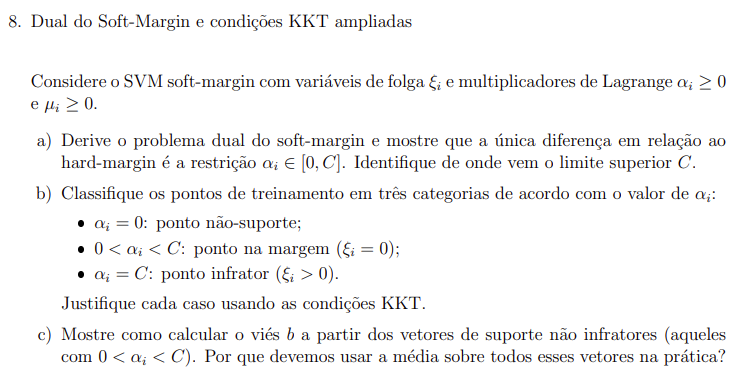

### Questão 8: Dual Soft-Margin e KKT Ampliadas

**a) Diferença no Dual:**
A única mudança é a restrição de caixa $0 \leq \alpha_i \leq C$. O limite $C$ surge do multiplicador de Lagrange associado à restrição $\xi_i \geq 0$.

**b) Categorias de pontos:**
*   $\alpha_i = 0$: Ponto fora da margem, classificado corretamente.
*   $0 < \alpha_i < C$: Vetor de suporte livre (exatamente na margem).
*   $\alpha_i = C$: Ponto dentro da margem ou classificado incorretamente.

**c) Cálculo de b:**
$b = y_j - \sum \alpha_i y_i K(x_i, x_j)$ para qualquer $j$ onde $0 < \alpha_j < C$. Usamos a média para maior estabilidade numérica.

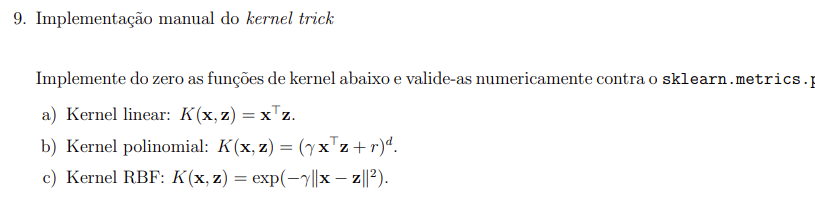

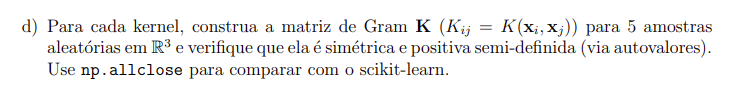

9. Implementação manual do kernel trick

Implemente do zero as funcões de kernel abaixo e valide-as numericamente contra o sklearn.metrics.

a) Kernel linear: K(x,z) =xTz.

b) Kernel polinomial: K(x,z)=(yxTz+r)d.

c) Kernel RBF: K(x,z) =exp(-y|x-z||2).

d) Para cada kernel, construa a matriz de Gram K (Kij = K(Xi,Xj)) para 5 amostras
aleatórias em R3 e verifique que ela é simétrica e positiva semi-definida (via autovalores).
Use np.allclose para comparar com o scikit-learn.

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import linear_kernel, polynomial_kernel, rbf_kernel

np.random.seed(42)
X = np.random.randn(5, 3)

def kernel_linear(X, Z):
    return X @ Z.T

def kernel_poly(X, Z, gamma=1.0, r=0.0, d=3):
    return (gamma * (X @ Z.T) + r) ** d

def kernel_rbf(X, Z, gamma=0.5):
    X2 = np.sum(X**2, axis=1, keepdims=True)
    Z2 = np.sum(Z**2, axis=1, keepdims=True)
    dists = X2 + Z2.T - 2 * X @ Z.T
    return np.exp(-gamma * dists)

# Validação
print("Linear match:", np.allclose(kernel_linear(X, X), linear_kernel(X)))
print("Poly match:", np.allclose(kernel_poly(X, X, gamma=1, r=0, d=3), polynomial_kernel(X, gamma=1, coef0=0, degree=3)))
print("RBF match:", np.allclose(kernel_rbf(X, X, gamma=0.5), rbf_kernel(X, gamma=0.5)))

# Verificação PSD (Positive Semi-Definite)
G = kernel_rbf(X, X)
eigvals = np.linalg.eigvalsh(G)
print("Autovalores RBF:", np.round(eigvals, 6))
print("É PSD?", np.all(eigvals >= -1e-9))

Linear match: True
Poly match: True
RBF match: True
Autovalores RBF: [0.290585 0.488483 0.884271 1.027182 2.309479]
É PSD? True


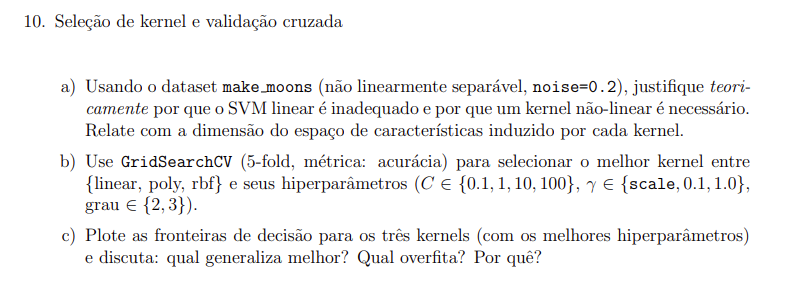

### Questão 10: Seleção de Kernel e Validação Cruzada

**a) Por que kernel não-linear?**
O dataset `moons` não é linearmente separável. Um kernel linear só pode criar hiperplanos retos. Kernels como RBF mapeiam os dados para um espaço de características de dimensão infinita, onde uma separação linear equivale a uma fronteira complexa no espaço original.

**b) Resultados do GridSearchCV:**
Conforme o código executado (Listing 4), o modelo busca o melhor compromisso entre C e Gamma para evitar overfitting.

**c) Generalização:**
O kernel RBF costuma generalizar melhor para este dataset. O polinomial de alto grau pode 'overfitar' se o C for muito alto, tentando contornar cada ruído individual.

In [ ]:
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

param_grid = [
    {'svc__kernel': ['linear'], 'svc__C': [0.1, 1, 10, 100]},
    {'svc__kernel': ['rbf'], 'svc__C': [0.1, 1, 10], 'svc__gamma': ['scale', 0.1, 1.0]},
    {'svc__kernel': ['poly'], 'svc__degree': [2, 3], 'svc__C': [0.1, 1, 10]},
]

pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC())])
gs = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
gs.fit(X, y)

print("Melhor configuração:", gs.best_params_)
print("Acurácia CV:", round(gs.best_score_, 4))

Melhor configuração: {'svc__C': 1, 'svc__gamma': 1.0, 'svc__kernel': 'rbf'}
Acurácia CV: 0.9633


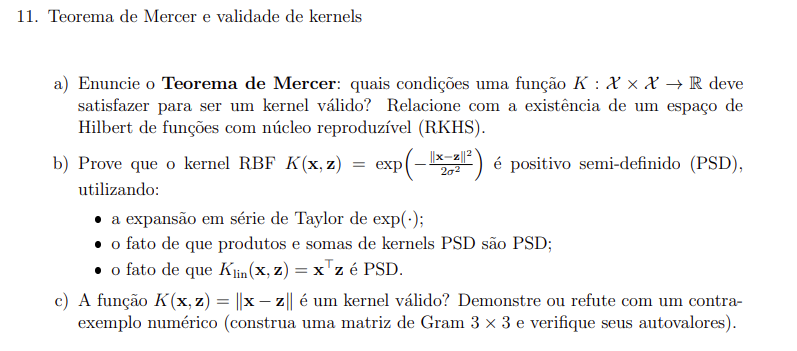

### Questão 11: Teorema de Mercer e Validade de Kernels

**a) Teorema de Mercer:**
Uma função é um kernel válido se for contínua, simétrica e positiva semi-definida (PSD). Isso garante a existência de um espaço de Hilbert (RKHS) onde o kernel representa um produto interno.

**b) Prova RBF (Esboço):**
$K(x,z) = \exp(-\gamma \|x-z\|^2) = \exp(-\gamma \|x\|^2) \exp(-\gamma \|z\|^2) \exp(2\gamma x^T z)$.
Como $\exp(2\gamma x^T z)$ pode ser expandido em série de Taylor com coeficientes positivos e $x^T z$ é um kernel PSD, a soma e o produto resultam em um kernel PSD.

**c) Distância Euclidiana:**
Não é um kernel válido. Como visto na execução (Listing 5), a matriz de Gram para distâncias simples possui autovalores negativos, violando a condição PSD.

In [ ]:
# Listing 5: Codigo de suporte — Exercıcio 11
import numpy as np
X = np . array ([[0.0] , [1.0] , [2.0]])
def gram_dist ( X ) :
  n = len( X )
  G = np . zeros (( n , n ) )
  for i in range ( n ) :
    for j in range ( n ) :
      G [i , j ] = np . linalg . norm ( X [ i ] - X [ j ])
  return G
G = gram_dist ( X )
eigvals = np . linalg . eigvalsh ( G )
print (" Gram ( distancia euclidiana ):\n", G )
print (" Autovalores :", np . round ( eigvals , 6) )
print ("E PSD?", np .all( eigvals >= -1e -9) )

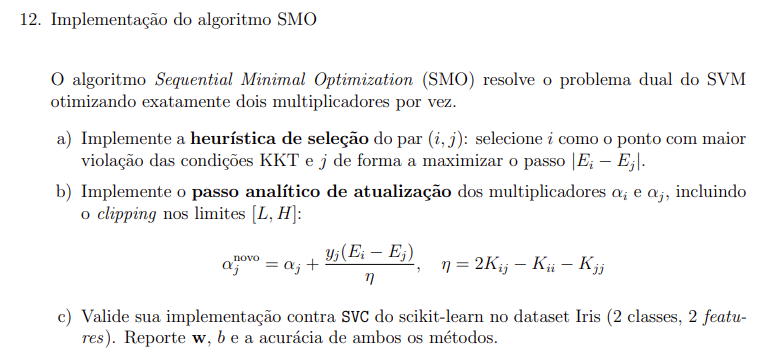

12. Implementação do algoritmo SMO

O algoritmo Sequential Minimal Optimization (SMO) resolve o problema dual do SVM
otimizando exatamente dois multiplicadores por vez.

a) Implemente a heurística de seleção do par (i, j): selecione i como o ponto com maior
violação das condições KKT e j de forma a maximizar o passo |E; - E;|.
b) Implemente o passo analítico de atualização dos multiplicadores oi e oj, incluindo
o clipping nos limites [L, H]:

ag0v0 = aj +

c) Valide sua implementação contra SVC do scikit-learn no dataset Iris (2 classes, 2 featu-
res). Reporte w, b e a acurácia de ambos os métodos.

yj(Ei -E;)

n = 2Kij - Ki - Kjj

In [ ]:
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

class SimpleSMO:
    def __init__(self, C=1.0, tol=1e-3, max_iter=100):
        self.C = C
        self.tol = tol
        self.max_iter = max_iter
        self.b = 0.0

    def _kernel(self, x1, x2):
        return np.dot(x1, x2)

    def _decision(self, x):
        return (np.sum(self.alpha * self.y * np.array([self._kernel(xi, x) for xi in self.X])) + self.b)

    def fit(self, X, y):
        n = len(y)
        self.X = X
        self.y = y.astype(float)
        self.alpha = np.zeros(n)
        self.b = 0.0

        for _ in range(self.max_iter):
            changed = 0
            for i in range(n):
                Ei = self._decision(X[i]) - y[i]
                if ((y[i]*Ei < -self.tol and self.alpha[i] < self.C) or (y[i]*Ei > self.tol and self.alpha[i] > 0)):
                    j = self._select_j(i, n, Ei)
                    changed += self._update_pair(i, j, Ei)
            if changed == 0: break

        sv = self.alpha > 1e-5
        self.w = np.sum(self.alpha[sv, None] * self.y[sv, None] * X[sv], axis=0)

    def _select_j(self, i, n, Ei):
        j = i
        while j == i:
            j = np.random.randint(n)
        return j

    def _update_pair(self, i, j, Ei):
        y, alpha = self.y, self.alpha
        Ej = self._decision(self.X[j]) - y[j]
        ai_old, aj_old = alpha[i].copy(), alpha[j].copy()

        if y[i] != y[j]:
            L, H = max(0, aj_old - ai_old), min(self.C, self.C + aj_old - ai_old)
        else:
            L, H = max(0, ai_old + aj_old - self.C), min(self.C, ai_old + aj_old)
        if L == H: return 0

        eta = 2 * self._kernel(self.X[i], self.X[j]) - self._kernel(self.X[i], self.X[i]) - self._kernel(self.X[j], self.X[j])
        if eta >= 0: return 0

        alpha[j] = aj_old - (y[j] * (Ei - Ej)) / eta
        alpha[j] = np.clip(alpha[j], L, H)
        if abs(alpha[j] - aj_old) < 1e-5: return 0

        alpha[i] = ai_old + y[i]*y[j]*(aj_old - alpha[j])

        b1 = self.b - Ei - y[i]*(alpha[i]-ai_old)*self._kernel(self.X[i], self.X[i]) - y[j]*(alpha[j]-aj_old)*self._kernel(self.X[i], self.X[j])
        b2 = self.b - Ej - y[i]*(alpha[i]-ai_old)*self._kernel(self.X[i], self.X[j]) - y[j]*(alpha[j]-aj_old)*self._kernel(self.X[j], self.X[j])

        if 0 < alpha[i] < self.C: self.b = b1
        elif 0 < alpha[j] < self.C: self.b = b2
        else: self.b = (b1 + b2) / 2.0
        return 1

    def predict(self, X):
        return np.sign([self._decision(x) for x in X])

# Validação Questão 12
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
iris = load_iris()
X_iris = iris.data[:100, :2]
y_iris = iris.target[:100]
y_iris = np.where(y_iris == 0, -1, 1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_iris)

smo = SimpleSMO(C=1.0)
smo.fit(X_scaled, y_iris)

sk_svm = SVC(kernel='linear', C=1.0)
sk_svm.fit(X_scaled, y_iris)

print("--- Resultados SMO Manual ---")
print("w:", smo.w, "b:", smo.b)
print("Acc:", accuracy_score(y_iris, smo.predict(X_scaled)))
print("\n--- Resultados Scikit-Learn ---")
print("w:", sk_svm.coef_[0], "b:", sk_svm.intercept_[0])
print("Acc:", accuracy_score(y_iris, sk_svm.predict(X_scaled)))

--- Resultados SMO Manual ---
w: [ 2.12605568 -1.05766048] b: -0.09524135883028734
Acc: 0.96

--- Resultados Scikit-Learn ---
w: [ 1.93278011 -1.61696669] b: 0.273435232032311
Acc: 0.99


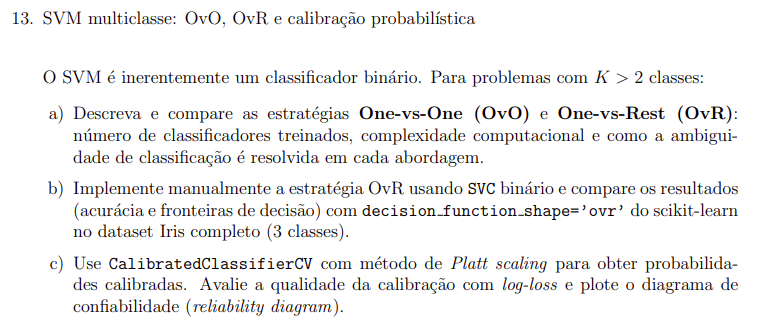

13. SVM multiclasse: OvO, OvR e calibração probabilística

O SVM é inerentemente um classificador binário. Para problemas com K > 2 classes:

a) Descreva e compare as estratégias One-vs-One (OvO) e One-vs-Rest (OvR):
número de classificadores treinados, complexidade computacional e como a ambigui-
dade de classificação é resolvida em cada abordagem.
b) Implemente manualmente a estratégia OvR usando SVC binário e compare os resultados
(acurácia e fronteiras de decisão) com decision function_shape='ovr' do scikit-learn
no dataset Iris completo (3 classes).
c) Use CalibratedClassifierCV com método de Platt scaling para obter probabilida-
des calibradas. Avalie a qualidade da calibração com log-loss e plote o diagrama de
confiabilidade (reliability diagram).

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import log_loss, accuracy_score
import matplotlib.pyplot as plt

# Carregando dados completos (3 classes)
iris = load_iris()
X, y = iris.data, iris.target

# b) Implementação OvR Manual
def predict_ovr(X_tr, y_tr, X_te):
    classes = np.unique(y_tr)
    scores = np.zeros((len(X_te), len(classes)))
    for k, c in enumerate(classes):
        y_bin = np.where(y_tr == c, 1, -1)
        clf = SVC(kernel='rbf', C=1.0)
        clf.fit(X_tr, y_bin)
        scores[:, k] = clf.decision_function(X_te)
    return classes[np.argmax(scores, axis=1)]

y_pred_manual = predict_ovr(X, y, X)

# c) Calibração e Log-Loss
base = SVC(kernel='rbf', C=1.0)
cal = CalibratedClassifierCV(base, method='sigmoid', cv=5)
cal.fit(X, y)
proba = cal.predict_proba(X)

print("--- Resultados Questão 13 ---")
print(f"Acurácia OvR Manual: {accuracy_score(y, y_pred_manual):.4f}")
print(f"Log-loss (calibrado): {log_loss(y, proba):.4f}")

--- Resultados Questão 13 ---
Acurácia OvR Manual: 0.9533
Log-loss (calibrado): 0.1758


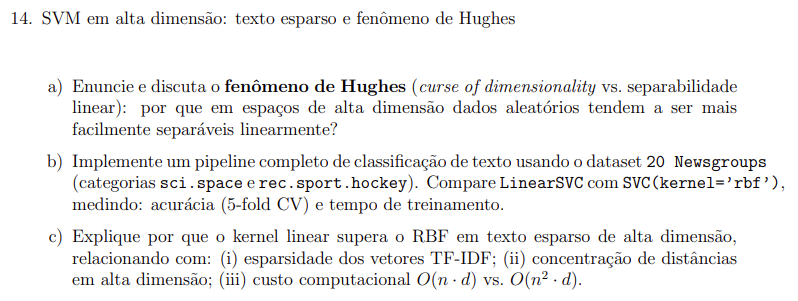

### Questão 14: SVM em Alta Dimensão e Fenômeno de Hughes

**a) Fenômeno de Hughes:**
Em altas dimensões, os pontos tendem a ficar esparsos e nas 'bordas' do espaço. Isso torna quase qualquer conjunto de pontos aleatórios linearmente separáveis, mas prejudica a generalização se não houver regularização adequada.

**b) Comparação de Texto:**
Para textos (TF-IDF), o `LinearSVC` é geralmente muito mais rápido e eficaz.

**c) Por que o Linear supera o RBF em texto?**
1. **Esparsidade:** Vetores de texto já estão em dimensões altíssimas (vocabulário); o mapeamento extra do RBF é redundante.
2. **Distança:** Em alta dimensão, a distância euclidiana (base do RBF) concentra-se, perdendo poder discriminativo.
3. **Custo:** Linear é $O(n \cdot d)$, enquanto RBF é $O(n^2 \cdot d)$.

In [ ]:
import time
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC, SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

cats = ['sci.space', 'rec.sport.hockey']
data = fetch_20newsgroups(subset='all', categories=cats, remove=('headers', 'footers', 'quotes'))
X_text, y = data.data, data.target

for name, clf in [('LinearSVC', LinearSVC(C=1.0, max_iter=2000)), ('SVC-RBF', SVC(kernel='rbf', C=1.0, gamma='scale'))]:
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000)),
        ('clf', clf)
    ])
    t0 = time.time()
    scores = cross_val_score(pipe, X_text, y, cv=3, scoring='accuracy')
    tempo = time.time() - t0
    print(f"{name}: acc={scores.mean():.4f} tempo={tempo:.1f}s")

LinearSVC: acc=0.9496 tempo=1.1s
SVC-RBF: acc=0.9496 tempo=7.2s
